# Medical VQA — Full Pipeline (Hopper-Clean Build)
**Cross-Domain Transfer and Efficient Adaptation of Vision-Language Models for Medical VQA**

| Setting | Value |
|---------|-------|
| Model | `llava-hf/llava-1.5-7b-hf` |
| Fine-tuning | QLoRA (4-bit NF4 + LoRA adapters) |
| Cluster | GMU Hopper — A100 80GB, 12 hrs |
| Datasets | VQA-RAD · PathVQA · SLAKE (English) |

**What changed vs. the original notebook:**
- Single `pip install` cell with `bitsandbytes==0.41.3` (works on Hopper; `0.43.1+` requires triton.ops which Hopper's triton doesn't have)
- `DTYPE` now set in Cell 0 so it survives kernel restarts without dependency on Cell 2
- Removed the redundant sentencepiece + bnb-downgrade emergency cells
- Added `PIL.ImageFile.LOAD_TRUNCATED_IMAGES = True` for PathVQA TIFF warnings
- HF token now read from environment variable (not hardcoded)


## Cell 0 — Environment Detection, Paths & DTYPE


In [1]:
import os
os.environ['BNB_CUDA_VERSION'] = '122'   # MUST be set before any torch/bnb import

import sys, platform
import torch
from PIL import ImageFile
import warnings

# Fix PIL truncated-file warnings for PathVQA TIFFs
ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings('ignore', message='Truncated File Read')

# ── Detect environment ─────────────
ON_KAGGLE  = os.path.exists('/kaggle')
ON_HOPPER  = 'SLURM_JOB_ID' in os.environ or os.path.exists('/scratch')
ON_LOCAL   = not ON_KAGGLE and not ON_HOPPER

ENV_NAME = 'kaggle' if ON_KAGGLE else ('hopper' if ON_HOPPER else 'local')
print(f'Running on: {ENV_NAME}')

# ── Paths ─────────────────────────────────────────────────────────────────────
if ON_HOPPER:
    SCRATCH      = os.environ.get('SCRATCH', f"/scratch/{os.environ.get('USER', 'user')}")
    CACHE_DIR    = f"{SCRATCH}/hf_cache"
    CKPT_DIR     = f"{SCRATCH}/vqa_checkpoints"
    RESULTS_DIR  = f"{SCRATCH}/vqa_results"
elif ON_KAGGLE:
    CACHE_DIR    = '/kaggle/working/hf_cache'
    CKPT_DIR     = '/kaggle/working/checkpoints'
    RESULTS_DIR  = '/kaggle/working/results'
else:
    CACHE_DIR    = './hf_cache'
    CKPT_DIR     = './checkpoints'
    RESULTS_DIR  = './results'

for d in [CACHE_DIR, CKPT_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

# Point HuggingFace libraries at scratch cache
os.environ['HF_HOME']           = CACHE_DIR
os.environ['HF_DATASETS_CACHE'] = os.path.join(CACHE_DIR, 'datasets')
# TRANSFORMERS_CACHE is deprecated in 4.44+; HF_HOME supersedes it

# ── DTYPE & device (moved here so it survives before model load) ─────────────
if torch.cuda.is_available():
    TARGET_GPU = 'cuda'
    cap = torch.cuda.get_device_capability()[0]
    DTYPE = torch.bfloat16 if cap >= 8 else torch.float16
else:
    TARGET_GPU = 'cpu'
    DTYPE = torch.float32

print(f'CACHE_DIR   : {CACHE_DIR}')
print(f'CKPT_DIR    : {CKPT_DIR}')
print(f'RESULTS_DIR : {RESULTS_DIR}')
print(f'Python      : {sys.version.split()[0]}')
print(f'Platform    : {platform.platform()}')
print(f'DTYPE       : {DTYPE}')
print(f'TARGET_GPU  : {TARGET_GPU}')

if ON_HOPPER:
    print(f"SLURM Job   : {os.environ.get('SLURM_JOB_ID', 'N/A')}")
    print(f"Node        : {os.environ.get('SLURMD_NODENAME', 'N/A')}")
    print(f"GPUs alloc  : {os.environ.get('SLURM_GPUS_ON_NODE', os.environ.get('CUDA_VISIBLE_DEVICES', 'N/A'))}")


Running on: hopper
CACHE_DIR   : /scratch/mdesai23/hf_cache
CKPT_DIR    : /scratch/mdesai23/vqa_checkpoints
RESULTS_DIR : /scratch/mdesai23/vqa_results
Python      : 3.9.9
Platform    : Linux-4.18.0-553.33.1.el8_10.x86_64-x86_64-with-glibc2.28
DTYPE       : torch.bfloat16
TARGET_GPU  : cuda
SLURM Job   : 7006466
Node        : gpu013
GPUs alloc  : 1


## Cell 1 — Install Packages (Hopper-safe pins)

> **Run once per job allocation.** Hopper does NOT persist pip installs across jobs.
> 
> **After this cell completes, RESTART THE KERNEL** before running Cell 2 onward.
> (Kernel → Restart Kernel, or press `Esc` then `0` twice.)


In [2]:
import subprocess, sys

# ── Pinned versions that are known-stable on Hopper (A100 80GB, GLIBC 2.28) ──
# bitsandbytes 0.43.1+ requires triton.ops.matmul_perf_model which is not in
# Hopper's bundled triton → crashes model load. 0.41.3 has no triton dep.
PACKAGES = [
    "safetensors>=0.4.1",
    "transformers==4.44.2",
    "peft==0.10.0",
    "bitsandbytes==0.41.3",   # pinned — do NOT bump without testing on Hopper
    "accelerate==0.29.3",
    "datasets==2.19.0",
    "tokenizers==0.19.1",
    "sentencepiece",
    "numpy==1.26.4",
    "Pillow",
    "matplotlib",
    "scikit-learn",
    "tqdm",
]

def pip_install(packages):
    cmd = [sys.executable, "-m", "pip", "install", "--upgrade"] + packages
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print("STDERR:", result.stderr[-2000:])
        raise RuntimeError("pip install failed")
    print(result.stdout[-500:] if result.stdout else "Done.")

pip_install(PACKAGES)

# Verify bitsandbytes is the right version
import importlib.util
spec = importlib.util.find_spec("bitsandbytes")
print("\nbitsandbytes location:", spec.origin if spec else "NOT FOUND")
print("\n>>> NOW RESTART THE KERNEL before continuing to Cell 2 <<<")


.0)


bitsandbytes location: /home/mdesai23/.local/lib/python3.9/site-packages/bitsandbytes/__init__.py

>>> NOW RESTART THE KERNEL before continuing to Cell 2 <<<


## Cell 2 — GPU Check & HuggingFace Login

> **Assumes you restarted the kernel after Cell 1.** If you skipped the restart, `bitsandbytes` will fail to import later.
> 
> **Before running:** set your HF token as an environment variable in your Hopper shell before launching Jupyter:
> ```bash
> export HF_TOKEN='hf_your_new_token_here'
> ```
> Or pass it through Kaggle Secrets if running on Kaggle.


In [11]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "bitsandbytes"],
               capture_output=True, text=True)
print("bitsandbytes uninstalled.")

bitsandbytes uninstalled.


In [2]:
import torch, os
from huggingface_hub import login


# ── GPU inventory ─────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        free, total = torch.cuda.mem_get_info(i)
        print(f"GPU {i}: {props.name}")
        print(f"       Total VRAM : {total/1024**3:.1f} GB")
        print(f"       Free  VRAM : {free/1024**3:.1f} GB")
        print(f"       Compute    : {props.major}.{props.minor}")
    print(f"\nUsing dtype: {DTYPE}")
else:
    print("WARNING: No CUDA GPU found — running in CPU mode (inference only)")

# ── HuggingFace login ────────────────────────────────────────────────────────
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    # Fallback: prompt interactively
    from getpass import getpass
    HF_TOKEN = getpass("Paste HF token (or set $HF_TOKEN env var): ")

login(token=HF_TOKEN, add_to_git_credential=False)
print("Logged in to HuggingFace Hub.")


GPU 0: NVIDIA A100-SXM4-80GB MIG 3g.40gb
       Total VRAM : 39.2 GB
       Free  VRAM : 39.0 GB
       Compute    : 8.0

Using dtype: torch.bfloat16
Paste HF token (or set $HF_TOKEN env var): ········
Logged in to HuggingFace Hub.


## Cell 3 — Load All Three Datasets


In [3]:
import pandas as pd
from datasets import load_dataset
from PIL import Image

DATASET_IDS = {
    'vqa_rad' : ('flaviagiammarino/vqa-rad',          None),
    'path_vqa': ('flaviagiammarino/path-vqa',         None),
    'slake'   : ('mdwiratathya/SLAKE-vqa-english',    None),
}

def load_all_datasets():
    splits = {}
    for name, (hf_id, cfg) in DATASET_IDS.items():
        print(f"Loading {name} from {hf_id} ...", end=' ', flush=True)
        try:
            kwargs = dict(cache_dir=os.path.join(CACHE_DIR, 'datasets'))
            if cfg:
                kwargs['name'] = cfg
            ds = load_dataset(hf_id, **kwargs)
            splits[name] = ds
            print(f"OK  — splits: {list(ds.keys())}")
        except Exception as e:
            print(f"FAILED — {e}")
    return splits

datasets_dict = load_all_datasets()

rad_ds   = datasets_dict['vqa_rad']
path_ds  = datasets_dict['path_vqa']
slake_ds = datasets_dict['slake']

print("\n── Dataset sizes ────────────────────────")
for name, ds in datasets_dict.items():
    for split, data in ds.items():
        print(f"  {name:10s} / {split:10s}: {len(data):6,} rows")


Loading vqa_rad from flaviagiammarino/vqa-rad ... OK  — splits: ['train', 'test']
Loading path_vqa from flaviagiammarino/path-vqa ... OK  — splits: ['train', 'validation', 'test']
Loading slake from mdwiratathya/SLAKE-vqa-english ... OK  — splits: ['train', 'validation', 'test']

── Dataset sizes ────────────────────────
  vqa_rad    / train     :  1,793 rows
  vqa_rad    / test      :    451 rows
  path_vqa   / train     : 19,654 rows
  path_vqa   / validation:  6,259 rows
  path_vqa   / test      :  6,719 rows
  slake      / train     :  4,919 rows
  slake      / validation:  1,053 rows
  slake      / test      :  1,061 rows


## Cell 4 — Dataset Inspection & Answer-Type Classification


In [4]:
# ── Sample one row from each dataset ─────────────────────────────────────────
for name, ds in datasets_dict.items():
    split = list(ds.keys())[0]
    row = ds[split][0]
    print(f"\n[{name}] split={split}")
    print(f"  Q : {row['question']}")
    print(f"  A : {row['answer']}")
    img = row['image']
    print(f"  img: {img.mode}  {img.size}")

# ── Answer-type tagging (CLOSED = yes/no, OPEN = everything else) ────────────
CLOSED_ANSWERS = {'yes', 'no'}

def tag_answer_type(example):
    answer_lower = str(example['answer']).strip().lower()
    example['answer_type'] = 'CLOSED' if answer_lower in CLOSED_ANSWERS else 'OPEN'
    return example

print("\n── Adding answer_type column ──────────────")
for name in datasets_dict:
    datasets_dict[name] = datasets_dict[name].map(tag_answer_type)
    for split, data in datasets_dict[name].items():
        closed = sum(1 for x in data if x['answer_type'] == 'CLOSED')
        open_  = len(data) - closed
        print(f"  {name:10s}/{split:10s}: CLOSED={closed:5,} ({100*closed/len(data):.1f}%)  OPEN={open_:5,}")

rad_ds   = datasets_dict['vqa_rad']
path_ds  = datasets_dict['path_vqa']
slake_ds = datasets_dict['slake']



[vqa_rad] split=train
  Q : are regions of the brain infarcted?
  A : yes
  img: RGB  (566, 555)

[path_vqa] split=train
  Q : where are liver stem cells (oval cells) located?
  A : in the canals of hering
  img: CMYK  (309, 272)

[slake] split=train
  Q : What modality is used to take this image?
  A : MRI
  img: RGB  (256, 256)

── Adding answer_type column ──────────────
  vqa_rad   /train     : CLOSED=  940 (52.4%)  OPEN=  853
  vqa_rad   /test      : CLOSED=  251 (55.7%)  OPEN=  200
  path_vqa  /train     : CLOSED=9,751 (49.6%)  OPEN=9,903
  path_vqa  /validation: CLOSED=3,125 (49.9%)  OPEN=3,134
  path_vqa  /test      : CLOSED=3,362 (50.0%)  OPEN=3,357
  slake     /train     : CLOSED=1,682 (34.2%)  OPEN=3,237
  slake     /validation: CLOSED=  358 (34.0%)  OPEN=  695
  slake     /test      : CLOSED=  355 (33.5%)  OPEN=  706


## Cell 5 — Visualize Sample Images (optional)


In [ ]:
import matplotlib.pyplot as plt
import random

def visualize_samples(rad, path, slake, n=3, seed=42):
    random.seed(seed)
    fig, axes = plt.subplots(n, 3, figsize=(18, 6*n))
    sources = [
        ('VQA-RAD (Radiology)',  rad['train']),
        ('PathVQA (Pathology)',  path['train']),
        ('SLAKE (Mixed English)', slake['train']),
    ]
    # Random indices so we see diverse images (PathVQA/SLAKE have many Qs/image)
    for col_idx, (title, ds) in enumerate(sources):
        idxs = random.sample(range(len(ds)), n)
        for row_idx, idx in enumerate(idxs):
            ax = axes[row_idx][col_idx]
            sample = ds[idx]
            img = sample['image'].convert('RGB')
            ax.imshow(img)
            q = sample['question'][:60] + ('...' if len(sample['question'])>60 else '')
            ax.set_title(f"{title}\nQ: {q}\nA: {sample['answer']}  [{sample['answer_type']}]",
                         fontsize=9)
            ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'dataset_samples.png'), dpi=100, bbox_inches='tight')
    plt.show()

visualize_samples(rad_ds, path_ds, slake_ds)


## Cell 6 — Load Model with QLoRA

> **Memory budget (A100 80GB):**
> - LLaVA-1.5-7B weights in NF4 ≈ ~4 GB  
> - Vision encoder (CLIP-ViT-L/14@336) ≈ ~0.6 GB  
> - LoRA adapters r=16 ≈ ~0.3 GB  
> - Activations + optimizer ≈ ~6–8 GB  
> - Total ≈ **~12–14 GB** → vast headroom on 80 GB
>
> On 80 GB you could skip QLoRA and load in bf16 directly for ~1–3% higher accuracy.
> Kept QLoRA here for reproducibility with Kaggle runs.


In [5]:
from transformers import (
    LlavaForConditionalGeneration,
    AutoProcessor,
)
import torch, gc

MODEL_ID = "llava-hf/llava-1.5-7b-hf"

def load_model_and_processor(model_id=MODEL_ID, cache_dir=CACHE_DIR):
    print(f"Loading processor from {model_id} ...")
    processor = AutoProcessor.from_pretrained(
        model_id,
        cache_dir=cache_dir,
        use_fast=False,
    )
    processor.tokenizer.padding_side = 'right'

    print(f"Loading model from {model_id} (bf16, no quantization) ...")
    model = LlavaForConditionalGeneration.from_pretrained(
        model_id,
        torch_dtype=DTYPE,           # bfloat16
        device_map="auto",
        cache_dir=cache_dir,
        low_cpu_mem_usage=True,
    )
    model.config.use_cache = False   # required for gradient checkpointing
    return model, processor

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

model, processor = load_model_and_processor()

# ── Memory report ─────────────────────────────────────────────────────────────
print("\n── GPU memory after model load ──────────")
for i in range(torch.cuda.device_count()):
    alloc = torch.cuda.memory_allocated(i) / 1024**3
    reserv = torch.cuda.memory_reserved(i)  / 1024**3
    total  = torch.cuda.get_device_properties(i).total_memory / 1024**3
    print(f"  GPU {i}: allocated={alloc:.2f}GB  reserved={reserv:.2f}GB  total={total:.1f}GB")

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal model params : {total_params/1e9:.2f}B")

Loading processor from llava-hf/llava-1.5-7b-hf ...


Some kwargs in processor config are unused and will not have any effect: num_additional_image_tokens, image_token, vision_feature_select_strategy, patch_size. 


Loading model from llava-hf/llava-1.5-7b-hf (bf16, no quantization) ...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]


── GPU memory after model load ──────────
  GPU 0: allocated=13.16GB  reserved=13.17GB  total=39.2GB

Total model params : 7.06B


In [7]:
import os
bnb_dir = '/home/mdesai23/.local/lib/python3.9/site-packages/bitsandbytes'
cuda_libs = sorted([f for f in os.listdir(bnb_dir) if 'libbitsandbytes_cuda' in f])
print(cuda_libs)

['libbitsandbytes_cuda110.so', 'libbitsandbytes_cuda110_nocublaslt.so', 'libbitsandbytes_cuda111.so', 'libbitsandbytes_cuda111_nocublaslt.so', 'libbitsandbytes_cuda114.so', 'libbitsandbytes_cuda114_nocublaslt.so', 'libbitsandbytes_cuda115.so', 'libbitsandbytes_cuda115_nocublaslt.so', 'libbitsandbytes_cuda117.so', 'libbitsandbytes_cuda117_nocublaslt.so', 'libbitsandbytes_cuda118.so', 'libbitsandbytes_cuda118_nocublaslt.so', 'libbitsandbytes_cuda120.so', 'libbitsandbytes_cuda120_nocublaslt.so', 'libbitsandbytes_cuda121.so', 'libbitsandbytes_cuda121_nocublaslt.so', 'libbitsandbytes_cuda122.so', 'libbitsandbytes_cuda122_nocublaslt.so']


## Cell 7 — Dataset Formatting Helper


In [6]:
from typing import Dict, Any

SYSTEM_PROMPT = (
    "You are a helpful medical imaging assistant. "
    "Answer the question about the provided medical image concisely."
)

def format_dataset(example: Dict[str, Any], include_answer: bool = True) -> Dict[str, Any]:
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": example['question']},
            ],
        }
    ]
    if include_answer:
        conversation.append({
            "role": "assistant",
            "content": [{"type": "text", "text": example['answer']}],
        })

    prompt = processor.apply_chat_template(
        conversation,
        add_generation_prompt=not include_answer,
    )
    image = example['image'].convert('RGB')

    inputs = processor(
        text=prompt,
        images=image,
        return_tensors='pt',
        padding=True,
    )
    return inputs

# ── Smoke test ────────────────────────────────────────────────────────────────
sample = rad_ds['train'][0]
inputs = format_dataset(sample, include_answer=False)
print("format_dataset() output keys:", list(inputs.keys()))
print("input_ids shape   :", inputs['input_ids'].shape)
print("pixel_values shape:", inputs['pixel_values'].shape)


format_dataset() output keys: ['input_ids', 'attention_mask', 'pixel_values']
input_ids shape   : torch.Size([1, 20])
pixel_values shape: torch.Size([1, 3, 336, 336])


## Cell 8 — Evaluate Function


In [12]:
import re, json
from tqdm import tqdm

def generate_answer(model, processor, image, question, max_new_tokens=64):
    example = {'image': image, 'question': question, 'answer': ''}
    inputs = format_dataset(example, include_answer=False)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
        )
    gen_ids = output_ids[0][inputs['input_ids'].shape[1]:]
    return processor.decode(gen_ids, skip_special_tokens=True).strip()


def evaluate(model, processor, dataset_split, max_samples=None, desc='Eval', shuffle=True, seed=42):
    model.eval()
    data = dataset_split
    if shuffle:
        data = data.shuffle(seed=seed)  # better image coverage for PathVQA/SLAKE (many Qs/img)
    if max_samples:
        data = data.select(range(min(max_samples, len(data))))

    results = {'closed': [], 'open': [], 'predictions': []}

    for row in tqdm(data, desc=desc):
        pred = generate_answer(model, processor, row['image'], row['question'])
        gold = str(row['answer']).strip().lower()
        pred_lower = pred.lower()

        if row['answer_type'] == 'CLOSED':
            correct = int(gold in pred_lower)
            results['closed'].append(correct)
        else:
            gold_tokens = re.findall(r'\w+', gold)
            correct = int(any(t in pred_lower for t in gold_tokens))
            results['open'].append(correct)

        results['predictions'].append({
            'question': row['question'],
            'gold'    : row['answer'],
            'pred'    : pred,
            'type'    : row['answer_type'],
            'correct' : correct,
        })

    n_closed = len(results['closed'])
    n_open   = len(results['open'])
    n_total  = n_closed + n_open

    closed_acc = sum(results['closed']) / n_closed if n_closed else 0.0
    open_rec   = sum(results['open'])   / n_open   if n_open   else 0.0
    overall    = (sum(results['closed']) + sum(results['open'])) / n_total if n_total else 0.0

    metrics = {
        'closed_acc'  : round(closed_acc * 100, 2),
        'open_recall' : round(open_rec   * 100, 2),
        'overall'     : round(overall    * 100, 2),
        'n_closed'    : n_closed,
        'n_open'      : n_open,
        'n_total'     : n_total,
    }
    print(f"  Closed acc  : {metrics['closed_acc']:.2f}%  (n={n_closed})")
    print(f"  Open recall : {metrics['open_recall']:.2f}%  (n={n_open})")
    print(f"  Overall     : {metrics['overall']:.2f}%  (n={n_total})")
    return metrics, results['predictions']


## Cell 9 — Zero-Shot Baseline (No Fine-tuning)
> Free result row for the paper. Expected: ~65% closed, ~35% open on VQA-RAD.


In [9]:
ZERO_SHOT_SAMPLES = 200

zero_shot_results = {}

for name, ds in datasets_dict.items():
    split_key = 'test' if 'test' in ds else list(ds.keys())[-1]
    print(f"\n── Zero-shot on {name} / {split_key} ({ZERO_SHOT_SAMPLES} samples) ──")
    metrics, preds = evaluate(
        model, processor,
        ds[split_key],
        max_samples=ZERO_SHOT_SAMPLES,
        desc=name,
    )
    zero_shot_results[name] = metrics

    out_path = os.path.join(RESULTS_DIR, f"zero_shot_{name}.json")
    with open(out_path, 'w') as f:
        json.dump({'metrics': metrics, 'predictions': preds}, f, indent=2)
    print(f"  Saved → {out_path}")

print("\n── Zero-Shot Summary ────────────────────────────────")
print(f"{'Dataset':12s} {'Closed%':>10s} {'Open%':>10s} {'Overall%':>10s}")
print("-" * 46)
for name, m in zero_shot_results.items():
    print(f"{name:12s} {m['closed_acc']:>10.2f} {m['open_recall']:>10.2f} {m['overall']:>10.2f}")



── Zero-shot on vqa_rad / test (200 samples) ──


vqa_rad: 100%|██████████| 200/200 [03:57<00:00,  1.19s/it]


  Closed acc  : 63.96%  (n=111)
  Open recall : 46.07%  (n=89)
  Overall     : 56.00%  (n=200)
  Saved → /scratch/mdesai23/vqa_results/zero_shot_vqa_rad.json

── Zero-shot on path_vqa / test (200 samples) ──


path_vqa: 100%|██████████| 200/200 [04:38<00:00,  1.39s/it]


  Closed acc  : 61.22%  (n=98)
  Open recall : 30.39%  (n=102)
  Overall     : 45.50%  (n=200)
  Saved → /scratch/mdesai23/vqa_results/zero_shot_path_vqa.json

── Zero-shot on slake / test (200 samples) ──


slake: 100%|██████████| 200/200 [02:46<00:00,  1.20it/s]

  Closed acc  : 62.90%  (n=62)
  Open recall : 50.00%  (n=138)
  Overall     : 54.00%  (n=200)
  Saved → /scratch/mdesai23/vqa_results/zero_shot_slake.json

── Zero-Shot Summary ────────────────────────────────
Dataset         Closed%      Open%   Overall%
----------------------------------------------
vqa_rad           63.96      46.07      56.00
path_vqa          61.22      30.39      45.50
slake             62.90      50.00      54.00


## Cell 10 — Attach LoRA Adapters (QLoRA)


In [7]:
from peft import LoraConfig, get_peft_model

LORA_R = 16

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_R * 2,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

# Enable gradient checkpointing manually (used to be inside prepare_model_for_kbit_training)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()

model = get_peft_model(model, lora_config)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params : {trainable:,}  ({100*trainable/total:.4f}% of total)")
print(f"Total params     : {total:,}")

gc.collect(); torch.cuda.empty_cache()
for i in range(torch.cuda.device_count()):
    alloc = torch.cuda.memory_allocated(i) / 1024**3
    print(f"GPU {i} after LoRA: {alloc:.2f} GB allocated")

Trainable params : 42,336,256  (0.5958% of total)
Total params     : 7,105,763,328
GPU 0 after LoRA: 13.24 GB allocated


## Cell 11 — Training Loop (QLoRA Fine-tuning)

**A100 80GB settings (bumped batch_size from 2→4 since we have headroom):**

| Param | Value | Reason |
|-------|-------|--------|
| batch_size | 4 | Was 2 for 40GB; A100 80GB comfortably fits 4 |
| grad_accum | 4 | effective batch = 16 (same as before) |
| epochs | 3 | fits comfortably in 12-hr window |
| lr | 2e-4 | standard for LoRA |
| bf16 | True | A100 native |


In [9]:
import math
from torch.utils.data import DataLoader, Dataset
from transformers import get_cosine_schedule_with_warmup
import torch.optim as optim
from tqdm import tqdm

TRAIN_CONFIG = {
    'batch_size'        : 2,    # was 2 for 40GB
    'grad_accum_steps'  : 8,    # was 8; effective batch stays at 16
    'num_epochs'        : 3,
    'learning_rate'     : 2e-4,
    'warmup_ratio'      : 0.03,
    'max_grad_norm'     : 1.0,
    'save_every_n_steps': 200,
    'log_every_n_steps' : 20,
}

class VQADataset(Dataset):
    def __init__(self, hf_split, processor, max_length=512):
        self.data       = hf_split
        self.processor  = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data[idx]
        inputs = format_dataset(row, include_answer=True)
        return {k: v.squeeze(0) for k, v in inputs.items()}


def collate_fn(batch):
    keys = batch[0].keys()
    out = {}
    for k in keys:
        tensors = [b[k] for b in batch]
        if k == 'pixel_values':
            out[k] = torch.stack(tensors)
        else:
            out[k] = torch.nn.utils.rnn.pad_sequence(
                tensors, batch_first=True,
                padding_value=processor.tokenizer.pad_token_id or 0
            )
    if 'input_ids' in out:
        labels = out['input_ids'].clone()
        labels[labels == (processor.tokenizer.pad_token_id or 0)] = -100
        out['labels'] = labels
    return out


def train_one_dataset(model, processor, train_split, dataset_name,
                      config=TRAIN_CONFIG, ckpt_dir=CKPT_DIR):
    model.train()
    torch_dataset = VQADataset(train_split, processor)
    loader = DataLoader(
        torch_dataset,
        batch_size=config['batch_size'],
        shuffle=True,
        num_workers=4,
        pin_memory=True,
        collate_fn=collate_fn,
    )

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config['learning_rate'],
        weight_decay=0.01,
    )

    total_steps = math.ceil(len(loader) / config['grad_accum_steps']) * config['num_epochs']
    warmup_steps = int(total_steps * config['warmup_ratio'])
    scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    scaler = torch.cuda.amp.GradScaler(enabled=(DTYPE == torch.float16))

    loss_history = []
    global_step = 0

    for epoch in range(config['num_epochs']):
        running_loss = 0.0
        optimizer.zero_grad()
        for step, batch in enumerate(tqdm(loader, desc=f"Epoch {epoch+1}/{config['num_epochs']}")):
            batch = {k: v.to(model.device) for k, v in batch.items()}

            with torch.cuda.amp.autocast(dtype=DTYPE):
                outputs = model(**batch)
                loss = outputs.loss / config['grad_accum_steps']

            scaler.scale(loss).backward()
            running_loss += loss.item()

            if (step + 1) % config['grad_accum_steps'] == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), config['max_grad_norm'])
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
                global_step += 1

                if global_step % config['log_every_n_steps'] == 0:
                    avg_loss = running_loss / config['log_every_n_steps']
                    loss_history.append({'step': global_step, 'loss': avg_loss})
                    print(f"  step={global_step:5d}  loss={avg_loss:.4f}  lr={scheduler.get_last_lr()[0]:.2e}")
                    running_loss = 0.0

                if global_step % config['save_every_n_steps'] == 0:
                    save_path = os.path.join(ckpt_dir, f"{dataset_name}_step{global_step}")
                    model.save_pretrained(save_path)
                    print(f"  Checkpoint saved → {save_path}")

    final_path = os.path.join(ckpt_dir, f"{dataset_name}_final")
    model.save_pretrained(final_path)
    print(f"Final adapter saved → {final_path}")
    return model, loss_history


print("Starting QLoRA training on VQA-RAD ...")
model, rad_loss_history = train_one_dataset(
    model, processor,
    train_split=rad_ds['train'],
    dataset_name='vqa_rad',
)

print("\nPost-training eval on VQA-RAD test:")
rad_ft_metrics, _ = evaluate(model, processor, rad_ds['test'], max_samples=451, desc='VQA-RAD FT', shuffle=False)
with open(os.path.join(RESULTS_DIR, 'vqa_rad_finetuned.json'), 'w') as f:
    json.dump(rad_ft_metrics, f, indent=2)


/tmp/ipykernel_208739/1802839343.py:75: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DTYPE == torch.float16))


Starting QLoRA training on VQA-RAD ...


Epoch 1/3:   0%|          | 0/897 [00:00<?, ?it/s]/tmp/ipykernel_208739/1802839343.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=DTYPE):
/home/mdesai23/.local/lib/python3.9/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
Epoch 1/3:  18%|█▊        | 160/897 [02:20<10:48,  1.14it/s]

  step=   20  loss=4.0523  lr=2.00e-04


Epoch 1/3:  36%|███▌      | 320/897 [04:40<08:26,  1.14it/s]

...

Epoch 3/3:  86%|████████▌ | 768/897 [11:11<01:53,  1.14it/s]

  step=  320  loss=0.5639  lr=1.64e-06


Epoch 3/3: 100%|██████████| 897/897 [13:03<00:00,  1.15it/s]


Final adapter saved → /scratch/mdesai23/vqa_checkpoints/vqa_rad_final

Post-training eval on VQA-RAD test:


NameError: name 'evaluate' is not defined

In [13]:
import os
print(os.listdir('/scratch/mdesai23/vqa_checkpoints/'))

['vqa_rad_final', 'vqa_rad_step200']


In [14]:
print("Post-training eval on VQA-RAD test (full 451 samples):")
rad_ft_metrics, rad_ft_preds = evaluate(
    model, processor, rad_ds['test'],
    max_samples=451, desc='VQA-RAD FT', shuffle=False
)

import json
with open(os.path.join(RESULTS_DIR, 'vqa_rad_finetuned.json'), 'w') as f:
    json.dump({'metrics': rad_ft_metrics, 'predictions': rad_ft_preds}, f, indent=2)
print(f"\nSaved → {os.path.join(RESULTS_DIR, 'vqa_rad_finetuned.json')}")

# Comparison table
print("\n── VQA-RAD: Zero-Shot vs. Fine-Tuned ──")
print(f"{'Metric':15s} {'Zero-Shot':>12s} {'Fine-Tuned':>12s} {'Δ':>8s}")
print("-"*50)
zs = {'closed_acc': 63.96, 'open_recall': 46.07, 'overall': 56.00}
for k in ['closed_acc', 'open_recall', 'overall']:
    delta = rad_ft_metrics[k] - zs[k]
    print(f"{k:15s} {zs[k]:>11.2f}% {rad_ft_metrics[k]:>11.2f}% {delta:>+7.2f}")

Post-training eval on VQA-RAD test (full 451 samples):


VQA-RAD FT: 100%|██████████| 451/451 [21:43<00:00,  2.89s/it]

  Closed acc  : 74.10%  (n=251)
  Open recall : 62.50%  (n=200)
  Overall     : 68.96%  (n=451)

Saved → /scratch/mdesai23/vqa_results/vqa_rad_finetuned.json

── VQA-RAD: Zero-Shot vs. Fine-Tuned ──
Metric             Zero-Shot   Fine-Tuned        Δ
--------------------------------------------------
closed_acc            63.96%       74.10%  +10.14
open_recall           46.07%       62.50%  +16.43
overall               56.00%       68.96%  +12.96


In [15]:
import shutil, os
shutil.copytree('/scratch/mdesai23/vqa_results',
                '/home/mdesai23/vqa_results_backup',
                dirs_exist_ok=True)
shutil.copytree('/scratch/mdesai23/vqa_checkpoints/vqa_rad_final',
                '/home/mdesai23/vqa_rad_lora_adapter',
                dirs_exist_ok=True)
print("Backed up to $HOME")

Backed up to $HOME


## Cell 12 — LoRA Rank Sweep (Pareto Analysis)


Clearing current fine-tuned model from GPU before sweep ...

Rank sweep: r = 4
Loading processor from llava-hf/llava-1.5-7b-hf ...


Some kwargs in processor config are unused and will not have any effect: num_additional_image_tokens, image_token, vision_feature_select_strategy, patch_size. 


Loading model from llava-hf/llava-1.5-7b-hf (bf16, no quantization) ...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipykernel_208739/1802839343.py:75: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DTYPE == torch.float16))


...

  step=  220  loss=0.6325  lr=3.67e-07


Epoch 2/2: 100%|██████████| 897/897 [13:24<00:00,  1.12it/s]


Final adapter saved → /scratch/mdesai23/vqa_checkpoints/sweep_r128_final


r=128: 100%|██████████| 200/200 [09:56<00:00,  2.98s/it]


  Closed acc  : 65.71%  (n=105)
  Open recall : 77.89%  (n=95)
  Overall     : 71.50%  (n=200)
Partial results saved (6/6 ranks done)


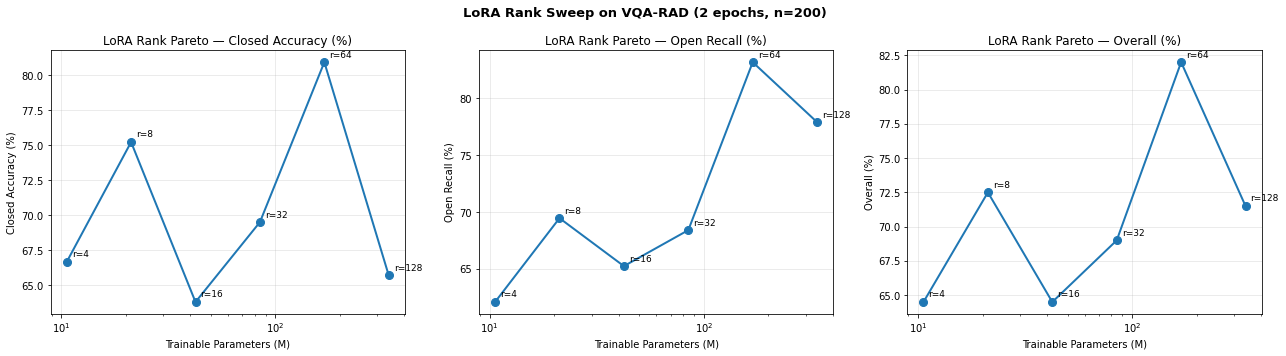


── Rank Sweep Results ──
   r    Params(M)    Closed%      Open%   Overall%
--------------------------------------------------
   4       10.58M     66.67%     62.11%     64.50%
   8       21.17M     75.24%     69.47%     72.50%
  16       42.34M     63.81%     65.26%     64.50%
  32       84.67M     69.52%     68.42%     69.00%
  64      169.35M     80.95%     83.16%     82.00%
 128      338.69M     65.71%     77.89%     71.50%

Pareto plot saved.


In [16]:
from peft import PeftModel, get_peft_model, LoraConfig
import copy, json, gc
import matplotlib.pyplot as plt

RANK_SWEEP = [4, 8, 16, 32, 64, 128]
SWEEP_EPOCHS = 2          # bumped from 1 — gives low ranks a fairer chance
SWEEP_SAMPLES_EVAL = 200

sweep_results = []

# Save the current fine-tuned model's reference so we can clean it up
# (the `model` var currently points to LoRA-adapted VQA-RAD model)
print("Clearing current fine-tuned model from GPU before sweep ...")
del model
gc.collect(); torch.cuda.empty_cache()

for r in RANK_SWEEP:
    print(f"\n{'='*50}")
    print(f"Rank sweep: r = {r}")
    print(f"{'='*50}")

    # Fresh base model per rank
    gc.collect(); torch.cuda.empty_cache()
    base_model, _ = load_model_and_processor()

    cfg = LoraConfig(
        r=r, lora_alpha=r*2,
        target_modules=["q_proj","k_proj","v_proj","o_proj",
                         "gate_proj","up_proj","down_proj"],
        lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
    )
    base_model.gradient_checkpointing_enable()
    base_model.enable_input_require_grads()
    base_model = get_peft_model(base_model, cfg)

    trainable = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
    print(f"Trainable params: {trainable:,}")

    sweep_config = {**TRAIN_CONFIG, 'num_epochs': SWEEP_EPOCHS}
    base_model, _ = train_one_dataset(
        base_model, processor,
        train_split=rad_ds['train'],
        dataset_name=f'sweep_r{r}',
        config=sweep_config,
    )

    metrics, _ = evaluate(
        base_model, processor,
        rad_ds['test'],
        max_samples=SWEEP_SAMPLES_EVAL,
        desc=f'r={r}',
        shuffle=False,   # deterministic across ranks for fair comparison
    )
    sweep_results.append({
        'rank'            : r,
        'trainable_params': trainable,
        **metrics,
    })

    # Aggressive cleanup — PEFT holds multiple refs
    del base_model
    import torch
    torch.cuda.synchronize()
    gc.collect()
    torch.cuda.empty_cache()

    # Save partial results after each rank — if we crash, we keep what we have
    with open(os.path.join(RESULTS_DIR, 'rank_sweep.json'), 'w') as f:
        json.dump(sweep_results, f, indent=2)
    print(f"Partial results saved ({len(sweep_results)}/{len(RANK_SWEEP)} ranks done)")

# ── Plot Pareto frontier ─────────────────────────────────────────────────────
ranks        = [x['rank'] for x in sweep_results]
param_counts = [x['trainable_params']/1e6 for x in sweep_results]
closed_accs  = [x['closed_acc'] for x in sweep_results]
open_recalls = [x['open_recall'] for x in sweep_results]
overalls     = [x['overall']    for x in sweep_results]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, vals, ylabel in zip(
    axes,
    [closed_accs, open_recalls, overalls],
    ['Closed Accuracy (%)', 'Open Recall (%)', 'Overall (%)'],
):
    ax.plot(param_counts, vals, 'o-', linewidth=2, markersize=8)
    for r, pc, v in zip(ranks, param_counts, vals):
        ax.annotate(f'r={r}', (pc, v), textcoords='offset points', xytext=(5,5), fontsize=9)
    ax.set_xlabel('Trainable Parameters (M)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'LoRA Rank Pareto — {ylabel}')
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')   # log x — param counts span 10M → 300M

plt.suptitle(f'LoRA Rank Sweep on VQA-RAD ({SWEEP_EPOCHS} epochs, n={SWEEP_SAMPLES_EVAL})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'pareto_rank_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print the table for the paper
print("\n── Rank Sweep Results ──")
print(f"{'r':>4s} {'Params(M)':>12s} {'Closed%':>10s} {'Open%':>10s} {'Overall%':>10s}")
print("-"*50)
for s in sweep_results:
    print(f"{s['rank']:>4d} {s['trainable_params']/1e6:>11.2f}M "
          f"{s['closed_acc']:>9.2f}% {s['open_recall']:>9.2f}% {s['overall']:>9.2f}%")

print("\nPareto plot saved.")

In [17]:
import shutil, os
HOME = os.path.expanduser('~')
backup = os.path.join(HOME, 'vqa_backup', 'results')
os.makedirs(backup, exist_ok=True)

shutil.copy('/scratch/mdesai23/vqa_results/rank_sweep.json', backup)
shutil.copy('/scratch/mdesai23/vqa_results/pareto_rank_sweep.png', backup)
print("Backed up rank sweep artifacts")
for f in ['rank_sweep.json', 'pareto_rank_sweep.png']:
    p = os.path.join(backup, f)
    print(f"  {p}  ({os.path.getsize(p):,} bytes)")

Backed up rank sweep artifacts
  /home/mdesai23/vqa_backup/results/rank_sweep.json  (1,137 bytes)
  /home/mdesai23/vqa_backup/results/pareto_rank_sweep.png  (145,101 bytes)


In [21]:
import os
p = '/home/mdesai23/vqa_bootstrap.py'
print(f"Exists: {os.path.exists(p)}  Size: {os.path.getsize(p) if os.path.exists(p) else 0:,} bytes")

Exists: True  Size: 11,171 bytes


In [19]:
import os

BOOTSTRAP_CODE = '''
# ════════════════════════════════════════════════════════════════════════
# BOOTSTRAP CELL — run this ONCE at start of new Jupyter session
# Rebuilds all state needed for Cell 13 (cross-domain transfer matrix)
# ════════════════════════════════════════════════════════════════════════

# ── 1. Env vars + paths ──────────────────────────────────────────────────
import os, sys, platform, warnings
os.environ["BNB_CUDA_VERSION"] = "122"  # harmless if bnb not installed
import torch
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore", message="Truncated File Read")

ON_HOPPER = "SLURM_JOB_ID" in os.environ or os.path.exists("/scratch")
if ON_HOPPER:
    SCRATCH     = os.environ.get("SCRATCH", f"/scratch/{os.environ.get('USER','user')}")
    CACHE_DIR   = f"{SCRATCH}/hf_cache"
    CKPT_DIR    = f"{SCRATCH}/vqa_checkpoints"
    RESULTS_DIR = f"{SCRATCH}/vqa_results"
else:
    CACHE_DIR, CKPT_DIR, RESULTS_DIR = "./hf_cache", "./checkpoints", "./results"

for d in [CACHE_DIR, CKPT_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)
os.environ["HF_HOME"]           = CACHE_DIR
os.environ["HF_DATASETS_CACHE"] = os.path.join(CACHE_DIR, "datasets")

DTYPE = torch.bfloat16 if torch.cuda.get_device_capability()[0] >= 8 else torch.float16
TARGET_GPU = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Paths OK  |  DTYPE={DTYPE}  |  device={TARGET_GPU}")

# ── 2. HuggingFace login ─────────────────────────────────────────────────
from huggingface_hub import login
HF_TOKEN = os.environ.get("HF_TOKEN")
if not HF_TOKEN:
    from getpass import getpass
    HF_TOKEN = getpass("HF token: ")
login(token=HF_TOKEN, add_to_git_credential=False)
print("HF login OK")

# ── 3. Load datasets (cached → fast) ─────────────────────────────────────
from datasets import load_dataset
DATASET_IDS = {
    "vqa_rad" : "flaviagiammarino/vqa-rad",
    "path_vqa": "flaviagiammarino/path-vqa",
    "slake"   : "mdwiratathya/SLAKE-vqa-english",
}
datasets_dict = {}
for name, hf_id in DATASET_IDS.items():
    datasets_dict[name] = load_dataset(hf_id, cache_dir=os.path.join(CACHE_DIR, "datasets"))

CLOSED_ANSWERS = {"yes", "no"}
def tag_answer_type(ex):
    ex["answer_type"] = "CLOSED" if str(ex["answer"]).strip().lower() in CLOSED_ANSWERS else "OPEN"
    return ex
for n in datasets_dict:
    datasets_dict[n] = datasets_dict[n].map(tag_answer_type)

rad_ds   = datasets_dict["vqa_rad"]
path_ds  = datasets_dict["path_vqa"]
slake_ds = datasets_dict["slake"]
print("Datasets loaded + tagged")

# ── 4. Model loader ──────────────────────────────────────────────────────
from transformers import LlavaForConditionalGeneration, AutoProcessor
import gc

MODEL_ID = "llava-hf/llava-1.5-7b-hf"

def load_model_and_processor(model_id=MODEL_ID, cache_dir=CACHE_DIR):
    print(f"Loading processor ...")
    processor = AutoProcessor.from_pretrained(model_id, cache_dir=cache_dir, use_fast=False)
    processor.tokenizer.padding_side = "right"
    print(f"Loading model (bf16) ...")
    model = LlavaForConditionalGeneration.from_pretrained(
        model_id, torch_dtype=DTYPE, device_map="auto",
        cache_dir=cache_dir, low_cpu_mem_usage=True,
    )
    model.config.use_cache = False
    return model, processor

print("load_model_and_processor defined")

# ── 5. Dataset formatter (Cell 7) ────────────────────────────────────────
# NOTE: uses `processor` from outer scope — Cell 13 loads processor per iteration,
# so we need a proc-aware version. We'll re-inject processor below.
_processor_global = None

def set_global_processor(p):
    global _processor_global
    _processor_global = p

def format_dataset(example, include_answer=True):
    p = _processor_global
    conv = [{"role": "user",
             "content": [{"type": "image"}, {"type": "text", "text": example["question"]}]}]
    if include_answer:
        conv.append({"role": "assistant",
                     "content": [{"type": "text", "text": example["answer"]}]})
    prompt = p.apply_chat_template(conv, add_generation_prompt=not include_answer)
    image = example["image"].convert("RGB")
    return p(text=prompt, images=image, return_tensors="pt", padding=True)

# ── 6. Eval functions (Cell 8) ───────────────────────────────────────────
import re, json
from tqdm import tqdm

def generate_answer(model, processor, image, question, max_new_tokens=64):
    ex = {"image": image, "question": question, "answer": ""}
    inputs = format_dataset(ex, include_answer=False)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.inference_mode():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens,
                             do_sample=False, temperature=None, top_p=None)
    gen_ids = out[0][inputs["input_ids"].shape[1]:]
    return processor.decode(gen_ids, skip_special_tokens=True).strip()

def evaluate(model, processor, dataset_split, max_samples=None, desc="Eval", shuffle=False, seed=42):
    set_global_processor(processor)
    model.eval()
    data = dataset_split
    if shuffle:
        data = data.shuffle(seed=seed)
    if max_samples:
        data = data.select(range(min(max_samples, len(data))))
    r_closed, r_open, r_preds = [], [], []
    for row in tqdm(data, desc=desc):
        pred = generate_answer(model, processor, row["image"], row["question"])
        gold = str(row["answer"]).strip().lower()
        pl = pred.lower()
        if row["answer_type"] == "CLOSED":
            correct = int(gold in pl); r_closed.append(correct)
        else:
            correct = int(any(t in pl for t in re.findall(r"\\w+", gold))); r_open.append(correct)
        r_preds.append({"question": row["question"], "gold": row["answer"],
                        "pred": pred, "type": row["answer_type"], "correct": correct})
    nc, no_ = len(r_closed), len(r_open); nt = nc + no_
    m = {
        "closed_acc" : round(100*sum(r_closed)/nc, 2) if nc else 0.0,
        "open_recall": round(100*sum(r_open)/no_, 2) if no_ else 0.0,
        "overall"    : round(100*(sum(r_closed)+sum(r_open))/nt, 2) if nt else 0.0,
        "n_closed"   : nc, "n_open": no_, "n_total": nt,
    }
    print(f"  Closed: {m['closed_acc']:.2f}%  Open: {m['open_recall']:.2f}%  Overall: {m['overall']:.2f}%")
    return m, r_preds

# ── 7. Training loop (Cell 11) ───────────────────────────────────────────
import math
from torch.utils.data import DataLoader, Dataset
from transformers import get_cosine_schedule_with_warmup
import torch.optim as optim

TRAIN_CONFIG = {
    "batch_size": 2, "grad_accum_steps": 8, "num_epochs": 3,
    "learning_rate": 2e-4, "warmup_ratio": 0.03, "max_grad_norm": 1.0,
    "save_every_n_steps": 200, "log_every_n_steps": 20,
}

class VQADataset(Dataset):
    def __init__(self, hf_split, processor):
        self.data = hf_split; set_global_processor(processor)
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        inputs = format_dataset(self.data[idx], include_answer=True)
        return {k: v.squeeze(0) for k, v in inputs.items()}

def make_collate_fn(processor):
    def collate_fn(batch):
        out = {}
        for k in batch[0].keys():
            ts = [b[k] for b in batch]
            if k == "pixel_values":
                out[k] = torch.stack(ts)
            else:
                out[k] = torch.nn.utils.rnn.pad_sequence(
                    ts, batch_first=True,
                    padding_value=processor.tokenizer.pad_token_id or 0)
        if "input_ids" in out:
            labels = out["input_ids"].clone()
            labels[labels == (processor.tokenizer.pad_token_id or 0)] = -100
            out["labels"] = labels
        return out
    return collate_fn

def train_one_dataset(model, processor, train_split, dataset_name,
                      config=TRAIN_CONFIG, ckpt_dir=CKPT_DIR):
    set_global_processor(processor)
    model.train()
    td = VQADataset(train_split, processor)
    loader = DataLoader(td, batch_size=config["batch_size"], shuffle=True,
                        num_workers=4, pin_memory=True,
                        collate_fn=make_collate_fn(processor))
    opt = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                      lr=config["learning_rate"], weight_decay=0.01)
    total = math.ceil(len(loader)/config["grad_accum_steps"])*config["num_epochs"]
    warm = int(total*config["warmup_ratio"])
    sch = get_cosine_schedule_with_warmup(opt, warm, total)
    scaler = torch.cuda.amp.GradScaler(enabled=(DTYPE==torch.float16))
    hist, gs = [], 0
    for ep in range(config["num_epochs"]):
        rl = 0.0; opt.zero_grad()
        for step, batch in enumerate(tqdm(loader, desc=f"Epoch {ep+1}/{config['num_epochs']}")):
            batch = {k: v.to(model.device) for k, v in batch.items()}
            with torch.cuda.amp.autocast(dtype=DTYPE):
                loss = model(**batch).loss / config["grad_accum_steps"]
            scaler.scale(loss).backward(); rl += loss.item()
            if (step+1) % config["grad_accum_steps"] == 0:
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), config["max_grad_norm"])
                scaler.step(opt); scaler.update(); sch.step(); opt.zero_grad(); gs += 1
                if gs % config["log_every_n_steps"] == 0:
                    avg = rl / config["log_every_n_steps"]; hist.append({"step": gs, "loss": avg})
                    print(f"  step={gs:5d}  loss={avg:.4f}  lr={sch.get_last_lr()[0]:.2e}"); rl = 0.0
                if gs % config["save_every_n_steps"] == 0:
                    sp = os.path.join(ckpt_dir, f"{dataset_name}_step{gs}")
                    model.save_pretrained(sp)
    fp = os.path.join(ckpt_dir, f"{dataset_name}_final")
    model.save_pretrained(fp)
    print(f"Final adapter: {fp}")
    return model, hist

print("train_one_dataset defined")

# ── 8. peft imports ──────────────────────────────────────────────────────
from peft import LoraConfig, get_peft_model
print("peft imports OK")

print("\\n" + "="*60)
print("BOOTSTRAP COMPLETE — ready for Cell 13")
print("="*60)
'''

# Write to both $HOME (persistent) and /scratch
HOME = os.path.expanduser('~')
for target_dir in [HOME, '/scratch/mdesai23']:
    path = os.path.join(target_dir, 'vqa_bootstrap.py')
    with open(path, 'w') as f:
        f.write(BOOTSTRAP_CODE)
    print(f"Saved → {path}  ({os.path.getsize(path):,} bytes)")

Saved → /home/mdesai23/vqa_bootstrap.py  (11,171 bytes)
Saved → /scratch/mdesai23/vqa_bootstrap.py  (11,171 bytes)


In [20]:
import shutil, os
HOME = os.path.expanduser('~')
backup = os.path.join(HOME, 'vqa_backup')
os.makedirs(backup, exist_ok=True)

# Adapter
shutil.copytree('/scratch/mdesai23/vqa_checkpoints/vqa_rad_final',
                os.path.join(backup, 'vqa_rad_lora_adapter'),
                dirs_exist_ok=True)
# Results JSONs
shutil.copytree('/scratch/mdesai23/vqa_results',
                os.path.join(backup, 'results'),
                dirs_exist_ok=True)

for f in os.listdir(backup):
    print(f"  {backup}/{f}")
print("Backup complete.")

  /home/mdesai23/vqa_backup/results
  /home/mdesai23/vqa_backup/vqa_rad_lora_adapter
Backup complete.


In [22]:
import os
HOME = os.path.expanduser('~')
print("── $HOME contents ──")
for root, dirs, files in os.walk(os.path.join(HOME, 'vqa_backup')):
    for f in files:
        p = os.path.join(root, f)
        print(f"  {p}  ({os.path.getsize(p):,} bytes)")
print(f"\nBootstrap: {HOME}/vqa_bootstrap.py  ({os.path.getsize(HOME+'/vqa_bootstrap.py'):,} bytes)")

── $HOME contents ──
  /home/mdesai23/vqa_backup/results/dataset_samples.png  (2,349,333 bytes)
  /home/mdesai23/vqa_backup/results/pareto_rank_sweep.png  (145,101 bytes)
  /home/mdesai23/vqa_backup/results/rank_sweep.json  (1,137 bytes)
  /home/mdesai23/vqa_backup/results/vqa_rad_finetuned.json  (111,063 bytes)
  /home/mdesai23/vqa_backup/results/zero_shot_path_vqa.json  (72,582 bytes)
  /home/mdesai23/vqa_backup/results/zero_shot_slake.json  (55,413 bytes)
  /home/mdesai23/vqa_backup/results/zero_shot_vqa_rad.json  (65,986 bytes)
  /home/mdesai23/vqa_backup/vqa_rad_lora_adapter/README.md  (5,098 bytes)
  /home/mdesai23/vqa_backup/vqa_rad_lora_adapter/adapter_config.json  (727 bytes)
  /home/mdesai23/vqa_backup/vqa_rad_lora_adapter/adapter_model.safetensors  (84,762,888 bytes)

Bootstrap: /home/mdesai23/vqa_bootstrap.py  (11,171 bytes)


## Cell 13 — Cross-Domain Transfer Matrix (3×3)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import json, gc
import torch

TRANSFER_RANK = 16
TRANSFER_EVAL_SAMPLES = 200

# Cap training at a fixed budget per dataset (fair comparison across uneven splits)
TRAIN_EPOCHS = 2
MAX_TRAIN_ROWS = 4000   # caps PathVQA (19,654) and SLAKE (4,919); VQA-RAD stays at 1,793

DOMAIN_DATASETS = {
    'vqa_rad' : rad_ds,
    'path_vqa': path_ds,
    'slake'   : slake_ds,
}

transfer_matrix = {}

# Free any existing model from GPU before starting
try:
    del model
except NameError:
    pass
gc.collect(); torch.cuda.empty_cache()

def reload_base_model():
    gc.collect(); torch.cuda.empty_cache()
    return load_model_and_processor()

for train_name, train_ds in DOMAIN_DATASETS.items():
    print(f"\n{'='*60}")
    print(f"Training on: {train_name}")
    print(f"{'='*60}")

    # Cap training size for fair compute budget
    train_split = train_ds['train']
    if len(train_split) > MAX_TRAIN_ROWS:
        print(f"  Capping training from {len(train_split):,} → {MAX_TRAIN_ROWS:,} rows (shuffled)")
        train_split = train_split.shuffle(seed=42).select(range(MAX_TRAIN_ROWS))

    base_model, processor = reload_base_model()
    cfg = LoraConfig(
        r=TRANSFER_RANK, lora_alpha=TRANSFER_RANK*2,
        target_modules=["q_proj","k_proj","v_proj","o_proj",
                         "gate_proj","up_proj","down_proj"],
        lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
    )
    base_model.gradient_checkpointing_enable()
    base_model.enable_input_require_grads()
    base_model = get_peft_model(base_model, cfg)

    base_model, _ = train_one_dataset(
        base_model, processor,
        train_split=train_split,
        dataset_name=f'transfer_{train_name}',
        config={**TRAIN_CONFIG, 'num_epochs': TRAIN_EPOCHS},
    )

    # Evaluate on all 3 test sets
    transfer_matrix[train_name] = {}
    for test_name, test_ds in DOMAIN_DATASETS.items():
        split_key = 'test' if 'test' in test_ds else list(test_ds.keys())[-1]
        print(f"  Eval on {test_name}/{split_key} ...")
        metrics, _ = evaluate(
            base_model, processor,
            test_ds[split_key],
            max_samples=TRANSFER_EVAL_SAMPLES,
            desc=f'{train_name}->{test_name}',
            shuffle=False,
        )
        transfer_matrix[train_name][test_name] = metrics

    # Save partial results after each train domain — crash-safe
    with open(os.path.join(RESULTS_DIR, 'transfer_matrix.json'), 'w') as f:
        json.dump(transfer_matrix, f, indent=2)
    print(f"  Partial matrix saved ({len(transfer_matrix)}/3 train domains done)")

    # Aggressive cleanup
    del base_model
    torch.cuda.synchronize()
    gc.collect()
    torch.cuda.empty_cache()

# ── Build matrices for plotting ──────────────────────────────────────────────
domains = list(DOMAIN_DATASETS.keys())
overall_matrix = np.array([[transfer_matrix[tr][te]['overall']    for te in domains] for tr in domains])
closed_matrix  = np.array([[transfer_matrix[tr][te]['closed_acc'] for te in domains] for tr in domains])
open_matrix    = np.array([[transfer_matrix[tr][te]['open_recall']for te in domains] for tr in domains])

print("\n── Cross-Domain Transfer Matrix (Overall %) ────────────")
header = f"{'Train/Test':12s}" + "".join(f"{d:>12s}" for d in domains)
print(header)
for i, tr in enumerate(domains):
    row = f"{tr:12s}" + "".join(f"{overall_matrix[i,j]:>12.2f}" for j in range(len(domains)))
    print(row)

# ── Plot 3 heatmaps side-by-side ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, mat, title in zip(
    axes,
    [closed_matrix, open_matrix, overall_matrix],
    ['Closed Accuracy', 'Open Recall', 'Overall'],
):
    im = ax.imshow(mat, cmap='YlOrRd', vmin=20, vmax=90)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(len(domains)))
    ax.set_yticks(range(len(domains)))
    ax.set_xticklabels([d.replace('_',' ').title() for d in domains])
    ax.set_yticklabels([d.replace('_',' ').title() for d in domains])
    ax.set_xlabel('Test Domain')
    ax.set_ylabel('Train Domain')
    ax.set_title(f'{title} (%)', fontweight='bold')
    for i in range(len(domains)):
        for j in range(len(domains)):
            ax.text(j, i, f"{mat[i,j]:.1f}",
                    ha='center', va='center', fontsize=11, fontweight='bold',
                    color='white' if mat[i,j] < 55 else 'black')

plt.suptitle(f'Cross-Domain Transfer Matrix (LoRA r={TRANSFER_RANK}, '
             f'{TRAIN_EPOCHS} epochs, max {MAX_TRAIN_ROWS} rows, LLaVA-1.5-7B)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'transfer_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Transfer matrix plot saved.")


Training on: vqa_rad
Loading processor from llava-hf/llava-1.5-7b-hf ...


Some kwargs in processor config are unused and will not have any effect: num_additional_image_tokens, image_token, vision_feature_select_strategy, patch_size. 


Loading model from llava-hf/llava-1.5-7b-hf (bf16, no quantization) ...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipykernel_208739/1802839343.py:75: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DTYPE == torch.float16))
Epoch 1/2:   0%|          | 0/897 [00:00<?, ?it/s]/tmp/ipykernel_208739/1802839343.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=DTYPE):
Epoch 1/2:  18%|█▊        | 160/897 [02:20<10:47,  1.14it/s]

...

Epoch 1/2:  48%|████▊     | 960/2000 [14:02<15:07,  1.15it/s]

  step=  120  loss=1.0139  lr=1.78e-04


Epoch 1/2:  56%|█████▌    | 1120/2000 [16:23<12:56,  1.13it/s]

  step=  140  loss=0.9889  lr=1.69e-04


Epoch 1/2:  60%|█████▉    | 1190/2000 [17:24<11:34,  1.17it/s]

## Cell 14 — CNN+LSTM Baseline


In [ ]:
import torchvision.models as tv_models
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset as TorchDataset
import torchvision.transforms as T

def build_vocab(dataset_split, min_freq=1):
    from collections import Counter
    counter = Counter()
    for row in dataset_split:
        tokens = row['question'].lower().split()
        counter.update(tokens)
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

class VQABaselineDataset(TorchDataset):
    IMG_TRANSFORM = T.Compose([
        T.Resize((224, 224)),
        T.Lambda(lambda img: img.convert('RGB')),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    def __init__(self, hf_split, vocab, answer_to_idx):
        self.data = hf_split
        self.vocab = vocab
        self.answer_to_idx = answer_to_idx

    def encode_question(self, question, max_len=20):
        tokens = question.lower().split()[:max_len]
        ids = [self.vocab.get(t, 1) for t in tokens]
        ids += [0] * (max_len - len(ids))
        return torch.tensor(ids, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data[idx]
        img   = self.IMG_TRANSFORM(row['image'])
        q_ids = self.encode_question(row['question'])
        ans   = self.answer_to_idx.get(str(row['answer']).lower(),
                                        self.answer_to_idx.get('<UNK>', 0))
        return img, q_ids, torch.tensor(ans, dtype=torch.long)


class CNNLSTMBaseline(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        cnn = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V1)
        cnn.fc = nn.Identity()
        self.cnn = cnn
        self.img_proj = nn.Linear(2048, hidden_dim)

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.q_proj = nn.Linear(hidden_dim * 2, hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, images, q_ids):
        img_feat = torch.relu(self.img_proj(self.cnn(images)))
        embeds   = self.embedding(q_ids)
        _, (h, _) = self.lstm(embeds)
        q_feat   = torch.relu(self.q_proj(torch.cat([h[0], h[1]], dim=-1)))
        fused    = torch.cat([img_feat, q_feat], dim=-1)
        return self.classifier(fused)


all_answers = list(set(str(row['answer']).lower() for row in rad_ds['train']))
answer_to_idx = {a: i for i, a in enumerate(sorted(all_answers))}
answer_to_idx['<UNK>'] = len(answer_to_idx)
idx_to_answer = {v: k for k, v in answer_to_idx.items()}

q_vocab = build_vocab(rad_ds['train'])

train_baseline_ds = VQABaselineDataset(rad_ds['train'], q_vocab, answer_to_idx)
test_baseline_ds  = VQABaselineDataset(rad_ds['test'],  q_vocab, answer_to_idx)

train_loader_b = DataLoader(train_baseline_ds, batch_size=32, shuffle=True, num_workers=4)
test_loader_b  = DataLoader(test_baseline_ds,  batch_size=32, shuffle=False, num_workers=4)

cnn_lstm = CNNLSTMBaseline(
    vocab_size=len(q_vocab),
    embed_dim=256,
    hidden_dim=512,
    num_classes=len(answer_to_idx),
).to(TARGET_GPU)

optimizer_b = optim.Adam(cnn_lstm.parameters(), lr=1e-3)
criterion   = nn.CrossEntropyLoss()

print("Training CNN+LSTM baseline ...")
for epoch in range(10):
    cnn_lstm.train()
    total_loss = 0
    for imgs, q_ids, labels in tqdm(train_loader_b, desc=f'Epoch {epoch+1}/10', leave=False):
        imgs, q_ids, labels = imgs.to(TARGET_GPU), q_ids.to(TARGET_GPU), labels.to(TARGET_GPU)
        optimizer_b.zero_grad()
        logits = cnn_lstm(imgs, q_ids)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer_b.step()
        total_loss += loss.item()

    cnn_lstm.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, q_ids, labels in test_loader_b:
            imgs, q_ids, labels = imgs.to(TARGET_GPU), q_ids.to(TARGET_GPU), labels.to(TARGET_GPU)
            preds = cnn_lstm(imgs, q_ids).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    acc = 100 * correct / total
    print(f"  Epoch {epoch+1:2d} | Loss={total_loss/len(train_loader_b):.4f} | Test Acc={acc:.2f}%")

baseline_result = {'cnn_lstm_vqa_rad_overall': acc}
with open(os.path.join(RESULTS_DIR, 'cnn_lstm_baseline.json'), 'w') as f:
    json.dump(baseline_result, f, indent=2)
print(f"CNN+LSTM baseline: {acc:.2f}% (VQA-RAD test)")


## Cell 15 — Final Results Summary Table


In [ ]:
import json, os

print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)

print("\n── Zero-Shot (no fine-tuning) ─────────────────────")
print(f"{'Dataset':12s} {'Closed%':>10s} {'Open%':>10s} {'Overall%':>10s}")
print("-"*45)
for name, m in zero_shot_results.items():
    print(f"{name:12s} {m['closed_acc']:>10.2f} {m['open_recall']:>10.2f} {m['overall']:>10.2f}")

print("\n── After QLoRA Fine-tuning on VQA-RAD (r=16) ─────")
print(f"  Closed  : {rad_ft_metrics['closed_acc']:.2f}%")
print(f"  Open    : {rad_ft_metrics['open_recall']:.2f}%")
print(f"  Overall : {rad_ft_metrics['overall']:.2f}%")

if sweep_results:
    best = max(sweep_results, key=lambda x: x['overall'])
    print(f"\n── LoRA Rank Sweep (best) ─────────────────────────")
    print(f"  Best rank  : r={best['rank']}")
    print(f"  Params     : {best['trainable_params']/1e6:.2f}M")
    print(f"  Overall    : {best['overall']:.2f}%")

print(f"\n── CNN+LSTM Baseline ──────────────────────────────")
print(f"  VQA-RAD Overall: {acc:.2f}%")

print("\n── Target Ranges (from proposal) ──────────────────")
targets = {
    'VQA-RAD Closed': '78–84%',
    'VQA-RAD Open'  : '55–68%',
    'SLAKE Closed'  : '81–87%',
    'PathVQA Closed': '82–88%',
}
for k, v in targets.items():
    print(f"  {k:20s}: {v}")

print("\nAll result files saved to:", RESULTS_DIR)
for f in os.listdir(RESULTS_DIR):
    print(f"  {f}")
